# PCR Prediction Model Development



In [145]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Load the Training Dataset


In [146]:
# Load the training dataset
train_data = pd.read_excel('TrainDataset2025_updated.xlsx')

train_data.head()


,ID,pCR (outcome),RelapseFreeSurvival (outcome),Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,Proliferation,HistologyType,LNStatus,TumourStage,Gene,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_Id,original_glcm_Idm,original_glcm_Idmn,original_glcm_Idn,original_glcm_Imc1,original_glcm_Imc2,original_glcm_InverseVariance,original_glcm_JointAverage,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_MCC,original_glcm_MaximumProbability,original_glcm_SumAverage,original_glcm_SumEntropy,original_glcm_SumSquares,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,missing_Gene
0,TRG002174,1,144.0,41.0,0,0.0,0.0,1,3.0,3.0,1.0,1.0,2,1.0,0.813912,0.724080,23.781937,32.844370,37.696154,38.626416,34.713110,39.572718,14209.458330,26.732440,0.771675,3676.500012,0.258736,14263,-0.163500,0.708860,2897.68930,0.738088,0.406537,4.594629,2.114799,0.278008,0.248168,0.217628,-1.251833,3.366632,0.174026,

In [147]:
# Drop unused columns
train_data = train_data.drop(columns=['RelapseFreeSurvival (outcome)', 'ID'])
train_data



,pCR (outcome),Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,Proliferation,HistologyType,LNStatus,TumourStage,Gene,original_shape_Elongation,original_shape_Flatness,original_shape_LeastAxisLength,original_shape_MajorAxisLength,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,original_firstorder_Median,original_firstorder_Minimum,original_firstorder_Range,original_firstorder_RobustMeanAbsoluteDeviation,original_firstorder_RootMeanSquared,original_firstorder_Skewness,original_firstorder_TotalEnergy,original_firstorder_Uniformity,original_firstorder_Variance,original_glcm_Autocorrelation,original_glcm_ClusterProminence,original_glcm_ClusterShade,original_glcm_ClusterTendency,original_glcm_Contrast,original_glcm_Correlation,original_glcm_DifferenceAverage,original_glcm_DifferenceEntropy,original_glcm_DifferenceVariance,original_glcm_Id,original_glcm_Idm,original_glcm_Idmn,original_glcm_Idn,original_glcm_Imc1,original_glcm_Imc2,original_glcm_InverseVariance,original_glcm_JointAverage,original_glcm_JointEnergy,original_glcm_JointEntropy,original_glcm_MCC,original_glcm_MaximumProbability,original_glcm_SumAverage,original_glcm_SumEntropy,original_glcm_SumSquares,original_gldm_DependenceEntropy,original_gldm_DependenceNonUniformity,original_gldm_DependenceNonUniformityNormalized,original_gldm_DependenceVariance,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis,original_glrlm_GrayLevelNonUniformity,original_glrlm_GrayLevelNonUniformityNormalized,original_glrlm_GrayLevelVariance,original_glrlm_HighGrayLevelRunEmphasis,original_glrlm_LongRunEmphasis,original_glrlm_LongRunHighGrayLevelEmphasis,original_glrlm_LongRunLowGrayLevelEmphasis,original_glrlm_LowGrayLevelRunEmphasis,original_glrlm_RunEntropy,original_glrlm_RunLengthNonUniformity,original_glrlm_RunLengthNonUniformityNormalized,original_glrlm_RunPercentage,original_glrlm_RunVariance,original_glrlm_ShortRunEmphasis,original_glrlm_ShortRunHighGrayLevelEmphasis,original_glrlm_ShortRunLowGrayLevelEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_GrayLevelNonUniformityNormalized,original_glszm_GrayLevelVariance,original_glszm_HighGrayLevelZoneEmphasis,original_glszm_LargeAreaEmphasis,original_glszm_LargeAreaHighGrayLevelEmphasis,original_glszm_LargeAreaLowGrayLevelEmphasis,original_glszm_LowGrayLevelZoneEmphasis,original_glszm_SizeZoneNonUniformity,original_glszm_SizeZoneNonUniformityNormalized,original_glszm_SmallAreaEmphasis,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,missing_Gene
0,1,41.0,0,0.0,0.0,1,3.0,3.0,1.0,1.0,2,1.0,0.813912,0.724080,23.781937,32.844370,37.696154,38.626416,34.713110,39.572718,14209.458330,26.732440,0.771675,3676.500012,0.258736,14263,-0.163500,0.708860,2897.689300,0.738088,0.406537,4.594629,2.114799,0.278008,0.248168,0.217628,-1.251833,3.366632,0.174026,0.450734,0.386237,2897.689300,0.670258,0.141574,

In [148]:
# Basic dataset information

print(f"Total samples: {train_data.shape[0]}")
print(f"Total features: {train_data.shape[1]}")
print(f"\nData types:")
print(train_data.dtypes.value_counts())
print(f"\nMissing values:")
missing = train_data.isnull().sum()

if missing[missing > 0].empty:
    print("No missing values found!")


Total samples: 400
Total features: 120

Data types:
float64    114
int64        6
Name: count, dtype: int64

Missing values:
No missing values found!


## Target Feature Distribution and Analysis


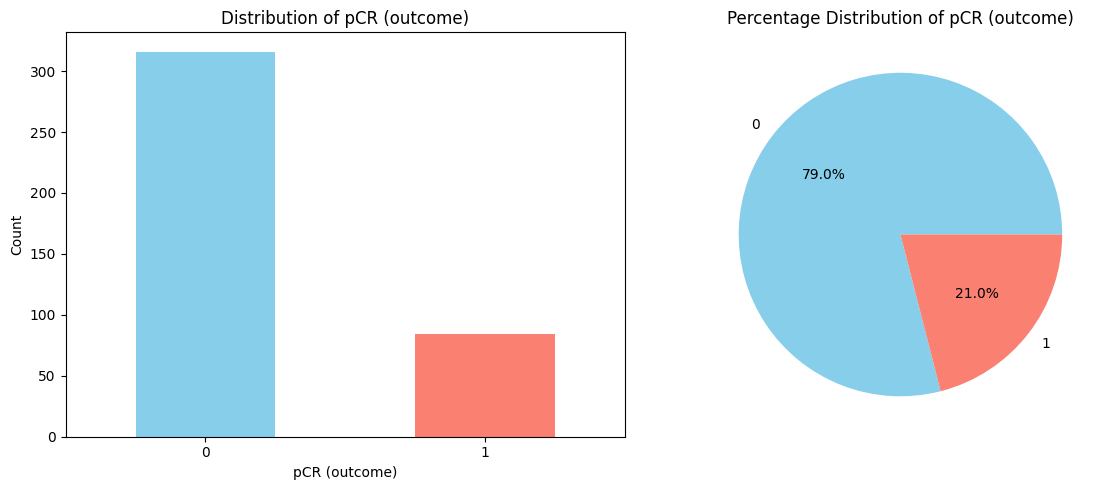

Class 0: 316 samples (79.00%)
Class 1: 84 samples (21.00%)


In [149]:
# Visualize the target distribution
TARGET_COLUMN = 'pCR (outcome)'
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
train_data[TARGET_COLUMN].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title(f'Distribution of {TARGET_COLUMN}')
axes[0].set_xlabel(TARGET_COLUMN)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
train_data[TARGET_COLUMN].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                                colors=['skyblue', 'salmon'])
axes[1].set_title(f'Percentage Distribution of {TARGET_COLUMN}')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Print class balance information
class_counts = train_data[TARGET_COLUMN].value_counts()

print(f"Class 0: {class_counts.iloc[0]} samples ({class_counts.iloc[0]/len(train_data)*100:.2f}%)")
print(f"Class 1: {class_counts.iloc[1]} samples ({class_counts.iloc[1]/len(train_data)*100:.2f}%)")



## Check for Categorical Variables


In [150]:

categorical_cols = []
numerical_cols = []

for col in train_data.columns:
    if col == TARGET_COLUMN:
        continue  # Skip target column
    
    dtype = train_data[col].dtype
    n_unique = train_data[col].nunique()
    n_total = len(train_data[col])
    
    # Check if it's categorical based on:
    # 1. Object dtype
    # 2. Low cardinality (< 20 unique values) with string/object type
    # 3. Integer type with very low cardinality (< 10) - might be encoded categorical
    if dtype == 'object':
        categorical_cols.append(col)
        print(f"\n{col} (Categorical - Object type):")
        print(f"  - Data type: {dtype}")
        print(f"  - Unique values: {n_unique}")
        print(f"  - Sample values: {train_data[col].unique()[:10]}")
    elif dtype in ['int64', 'int32'] and n_unique < 20:
        # Could be categorical - let's check the values
        unique_vals = train_data[col].unique()
        if all(val in [0, 1] for val in unique_vals) or n_unique < 10:
            categorical_cols.append(col)
            print(f"\n{col} (Potentially Categorical - Integer with low cardinality):")
            print(f"  - Data type: {dtype}")
            print(f"  - Unique values: {n_unique}")
            print(f"  - Values: {sorted(unique_vals)}")
    else:
        numerical_cols.append(col)

print(f"\n\nSummary:")
print(f"Total categorical columns: {len(categorical_cols)}")
print(f"Total numerical columns: {len(numerical_cols)}")
print(f"\nCategorical columns: {categorical_cols}")



ER (Potentially Categorical - Integer with low cardinality):
  - Data type: int64
  - Unique values: 2
  - Values: [0, 1]

TrippleNegative (Potentially Categorical - Integer with low cardinality):
  - Data type: int64
  - Unique values: 2
  - Values: [0, 1]

TumourStage (Potentially Categorical - Integer with low cardinality):
  - Data type: int64
  - Unique values: 4
  - Values: [1, 2, 3, 4]

missing_Gene (Potentially Categorical - Integer with low cardinality):
  - Data type: int64
  - Unique values: 2
  - Values: [0, 1]


Summary:
Total categorical columns: 4
Total numerical columns: 115

Categorical columns: ['ER', 'TrippleNegative', 'TumourStage', 'missing_Gene']


## Encode Categorical Variables


In [ ]:
# Create a copy of the dataset for encoding
train_data_encoded = train_data.copy()

# Store encoding mappings for later use (important for test data)
encoding_mappings = {}

# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

print("Encoding categorical variables...")
print("=" * 60)

for col in categorical_cols:
    print(f"\nEncoding '{col}':")
    
    # Use LabelEncoder for ordinal/nominal categorical variables
    le = LabelEncoder()
    
    # Fit and transform
    train_data_encoded[col] = le.fit_transform(train_data[col].astype(str))
    
    # Store the mapping for later use
    encoding_mappings[col] = {
        'encoder': le,
        'classes': le.classes_.tolist()
    }
    
    print(f"  - Original values: {train_data[col].unique()[:10]}")
    print(f"  - Encoded values: {train_data_encoded[col].unique()[:10]}")
    print(f"  - Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\n\nEncoding complete!")
print(f"Encoded dataset shape: {train_data_encoded.shape}")
print(f"Data types after encoding:")
print(train_data_encoded.dtypes.value_counts())


Encoding categorical variables...

Encoding 'ER':
  - Original values: [0 1]
  - Encoded values: [0 1]
  - Mapping: {'0': 0, '1': 1}

Encoding 'TrippleNegative':
  - Original values: [1 0]
  - Encoded values: [1 0]
  - Mapping: {'0': 0, '1': 1}

Encoding 'TumourStage':
  - Original values: [2 3 4 1]
  - Encoded values: [1 2 3 0]
  - Mapping: {'1': 0, '2': 1, '3': 2, '4': 3}

Encoding 'missing_Gene':
  - Original values: [0 1]
  - Encoded values: [0 1]
  - Mapping: {'0': 0, '1': 1}


Encoding complete!
Encoded dataset shape: (400, 120)
Data types after encoding:
float64    114
int32        4
int64        2
Name: count, dtype: int64


## Prepare Data for Feature Selection



In [152]:

X = train_data_encoded.drop(columns=[TARGET_COLUMN])
y = train_data_encoded[TARGET_COLUMN]

# Important features that must be retained
important_features = ['ER', 'HER2', 'Gene']


print(f"Features to always retain: {important_features}")
print(f"\nTotal features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")
print(f"Target distribution: {y.value_counts().to_dict()}")


Features to always retain: ['ER', 'HER2', 'Gene']

Total features: 119
Total samples: 400
Target distribution: {0: 316, 1: 84}


## Feature Selection Technique 1: ANOVA F-test


In [153]:
# ANOVA F-test Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

# Scale features for ANOVA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Test different k values
k_values = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
anova_results = {}

print("ANOVA F-test Feature Selection")
print("=" * 60)

for k in k_values:
    # Select k best features
    selector = SelectKBest(score_func=f_classif, k=k)
    X_selected = selector.fit_transform(X_scaled_df, y)
    selected_features = X_scaled_df.columns[selector.get_support()].tolist()
    
    # Ensure important features are included
    for imp_feat in important_features:
        if imp_feat not in selected_features:
            selected_features.append(imp_feat)
            # Remove one feature to keep k features
            if len(selected_features) > k:
                selected_features = selected_features[:k]
    
    # Evaluate with Random Forest
    X_final = X_scaled_df[selected_features]
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_final, y, cv=cv, scoring='balanced_accuracy')
    
    anova_results[k] = {
        'features': selected_features,
        'mean_score': scores.mean(),
        'std_score': scores.std(),
        'n_features': len(selected_features)
    }
    
    print(f"k={k}: Balanced Accuracy = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Find best k
best_k_anova = max(anova_results.keys(), key=lambda k: anova_results[k]['mean_score'])
print(f"\nBest k: {best_k_anova} with Balanced Accuracy = {anova_results[best_k_anova]['mean_score']:.4f}")
anova_selected_features = anova_results[best_k_anova]['features']


ANOVA F-test Feature Selection
k=5: Balanced Accuracy = 0.6049 (+/- 0.1290)
k=10: Balanced Accuracy = 0.5681 (+/- 0.0747)
k=20: Balanced Accuracy = 0.5589 (+/- 0.0644)
k=30: Balanced Accuracy = 0.5645 (+/- 0.0776)
k=40: Balanced Accuracy = 0.5511 (+/- 0.0535)
k=50: Balanced Accuracy = 0.5453 (+/- 0.0695)
k=60: Balanced Accuracy = 0.5316 (+/- 0.0478)
k=70: Balanced Accuracy = 0.5273 (+/- 0.0594)
k=80: Balanced Accuracy = 0.5124 (+/- 0.0361)
k=90: Balanced Accuracy = 0.5363 (+/- 0.0512)
k=100: Balanced Accuracy = 0.5253 (+/- 0.0320)

Best k: 5 with Balanced Accuracy = 0.6049


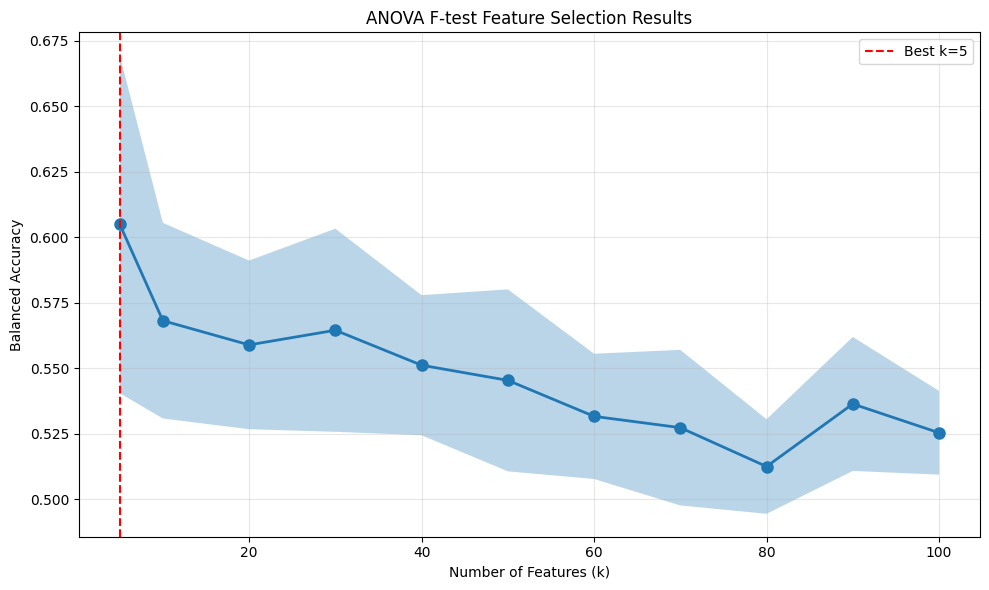


Selected 5 features using ANOVA (k=5)


In [154]:
# Visualize ANOVA results
fig, ax = plt.subplots(figsize=(10, 6))
k_vals = list(anova_results.keys())
scores = [anova_results[k]['mean_score'] for k in k_vals]
stds = [anova_results[k]['std_score'] for k in k_vals]

ax.plot(k_vals, scores, marker='o', linewidth=2, markersize=8)
ax.fill_between(k_vals, [s - std for s, std in zip(scores, stds)], 
                [s + std for s, std in zip(scores, stds)], alpha=0.3)
ax.axvline(best_k_anova, color='r', linestyle='--', label=f'Best k={best_k_anova}')
ax.set_xlabel('Number of Features (k)')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('ANOVA F-test Feature Selection Results')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSelected {len(anova_selected_features)} features using ANOVA (k={best_k_anova})")


## Feature Selection Technique 2: Chi-square Test


In [155]:
# Chi-square Feature Selection
from sklearn.feature_selection import chi2

# Chi-square works with non-negative values, so we need to handle negative values
# Discretize features for chi-square (binning)
X_discrete = X.copy()
for col in X_discrete.columns:
    if X_discrete[col].dtype in ['float64', 'float32']:
        X_discrete[col] = pd.qcut(X_discrete[col], q=5, labels=False, duplicates='drop')
        X_discrete[col] = X_discrete[col].fillna(0).astype(int)

# Test different k values
chi2_results = {}

print("Chi-square Feature Selection")
print("=" * 60)

for k in k_values:
    # Select k best features
    selector = SelectKBest(score_func=chi2, k=k)
    X_selected = selector.fit_transform(X_discrete, y)
    selected_features = X_discrete.columns[selector.get_support()].tolist()
    
    # Ensure important features are included
    for imp_feat in important_features:
        if imp_feat not in selected_features:
            selected_features.append(imp_feat)
            if len(selected_features) > k:
                selected_features = selected_features[:k]
    
    # Evaluate with Random Forest (use original scaled data)
    X_final = X_scaled_df[selected_features]
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_final, y, cv=cv, scoring='balanced_accuracy')
    
    chi2_results[k] = {
        'features': selected_features,
        'mean_score': scores.mean(),
        'std_score': scores.std(),
        'n_features': len(selected_features)
    }
    
    print(f"k={k}: Balanced Accuracy = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Find best k
best_k_chi2 = max(chi2_results.keys(), key=lambda k: chi2_results[k]['mean_score'])
print(f"\nBest k: {best_k_chi2} with Balanced Accuracy = {chi2_results[best_k_chi2]['mean_score']:.4f}")
chi2_selected_features = chi2_results[best_k_chi2]['features']


Chi-square Feature Selection
k=5: Balanced Accuracy = 0.5709 (+/- 0.0642)
k=10: Balanced Accuracy = 0.5459 (+/- 0.0986)
k=20: Balanced Accuracy = 0.5617 (+/- 0.0519)
k=30: Balanced Accuracy = 0.5283 (+/- 0.0275)
k=40: Balanced Accuracy = 0.5221 (+/- 0.0441)
k=50: Balanced Accuracy = 0.5311 (+/- 0.0245)
k=60: Balanced Accuracy = 0.5122 (+/- 0.0636)
k=70: Balanced Accuracy = 0.5072 (+/- 0.0657)
k=80: Balanced Accuracy = 0.5166 (+/- 0.0352)
k=90: Balanced Accuracy = 0.5135 (+/- 0.0218)
k=100: Balanced Accuracy = 0.5120 (+/- 0.0744)

Best k: 5 with Balanced Accuracy = 0.5709


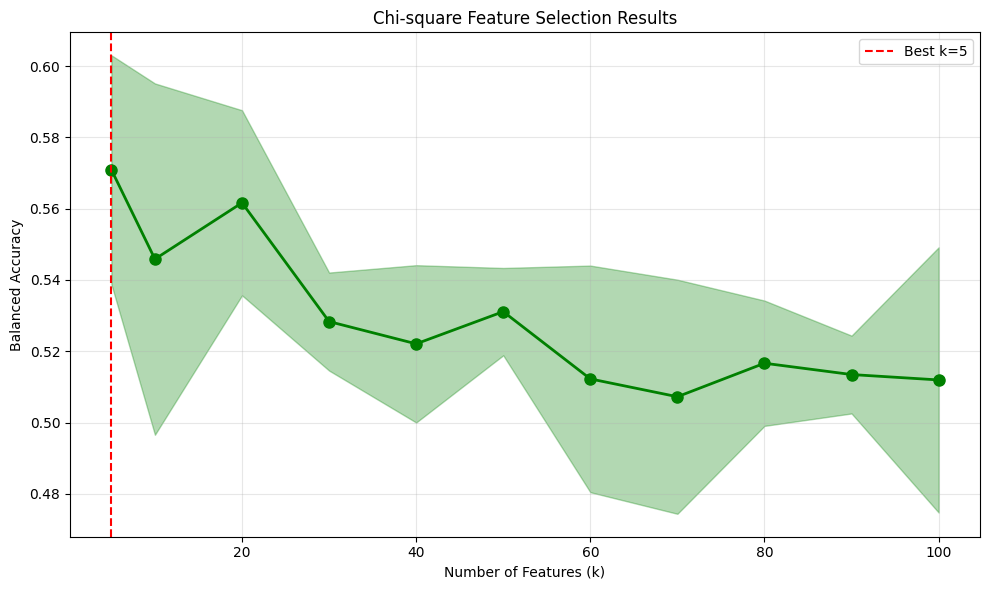


Selected 5 features using Chi-square (k=5)


In [156]:
# Visualize Chi-square results
fig, ax = plt.subplots(figsize=(10, 6))
k_vals = list(chi2_results.keys())
scores = [chi2_results[k]['mean_score'] for k in k_vals]
stds = [chi2_results[k]['std_score'] for k in k_vals]

ax.plot(k_vals, scores, marker='o', linewidth=2, markersize=8, color='green')
ax.fill_between(k_vals, [s - std for s, std in zip(scores, stds)], 
                [s + std for s, std in zip(scores, stds)], alpha=0.3, color='green')
ax.axvline(best_k_chi2, color='r', linestyle='--', label=f'Best k={best_k_chi2}')
ax.set_xlabel('Number of Features (k)')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Chi-square Feature Selection Results')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSelected {len(chi2_selected_features)} features using Chi-square (k={best_k_chi2})")


## Feature Selection Technique 3: Recursive Feature Elimination (RFE)


In [157]:
# RFE Feature Selection
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Test RFE with different estimators and k values
rfe_results = {}

print("RFE Feature Selection")
print("=" * 60)

# Test with Logistic Regression
estimators_rfe = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVC': SVC(kernel='linear', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=50, random_state=42)
}

for est_name, estimator in estimators_rfe.items():
    print(f"\nUsing {est_name}:")
    for k in [20, 30, 40, 50, 60, 70, 80]:
        selector = RFE(estimator=estimator, n_features_to_select=k, step=1)
        selector.fit(X_scaled_df, y)
        selected_features = X_scaled_df.columns[selector.get_support()].tolist()
        
        # Ensure important features are included
        for imp_feat in important_features:
            if imp_feat not in selected_features:
                selected_features.append(imp_feat)
                if len(selected_features) > k:
                    selected_features = selected_features[:k]
        
        # Evaluate
        X_final = X_scaled_df[selected_features]
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(rf, X_final, y, cv=cv, scoring='balanced_accuracy')
        
        key = f"{est_name}_k{k}"
        rfe_results[key] = {
            'features': selected_features,
            'mean_score': scores.mean(),
            'std_score': scores.std(),
            'n_features': len(selected_features),
            'estimator': est_name,
            'k': k
        }
        
        print(f"  k={k}: Balanced Accuracy = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Find best configuration
best_rfe = max(rfe_results.keys(), key=lambda k: rfe_results[k]['mean_score'])
print(f"\nBest RFE: {best_rfe} with Balanced Accuracy = {rfe_results[best_rfe]['mean_score']:.4f}")
rfe_selected_features = rfe_results[best_rfe]['features']


RFE Feature Selection

Using LogisticRegression:
  k=20: Balanced Accuracy = 0.5413 (+/- 0.0211)
  k=30: Balanced Accuracy = 0.5315 (+/- 0.0756)
  k=40: Balanced Accuracy = 0.5264 (+/- 0.0893)
  k=50: Balanced Accuracy = 0.5217 (+/- 0.0701)
  k=60: Balanced Accuracy = 0.5092 (+/- 0.0755)
  k=70: Balanced Accuracy = 0.5371 (+/- 0.0877)
  k=80: Balanced Accuracy = 0.5210 (+/- 0.0390)

Using SVC:
  k=20: Balanced Accuracy = 0.5440 (+/- 0.0481)
  k=30: Balanced Accuracy = 0.5334 (+/- 0.0369)
  k=40: Balanced Accuracy = 0.5296 (+/- 0.0450)
  k=50: Balanced Accuracy = 0.5260 (+/- 0.1316)
  k=60: Balanced Accuracy = 0.5340 (+/- 0.0684)
  k=70: Balanced Accuracy = 0.5193 (+/- 0.0674)
  k=80: Balanced Accuracy = 0.5136 (+/- 0.0618)

Using RandomForest:
  k=20: Balanced Accuracy = 0.5498 (+/- 0.0371)
  k=30: Balanced Accuracy = 0.5531 (+/- 0.0562)
  k=40: Balanced Accuracy = 0.5252 (+/- 0.0259)
  k=50: Balanced Accuracy = 0.5350 (+/- 0.0839)
  k=60: Balanced Accuracy = 0.5370 (+/- 0.0649)
  k=70

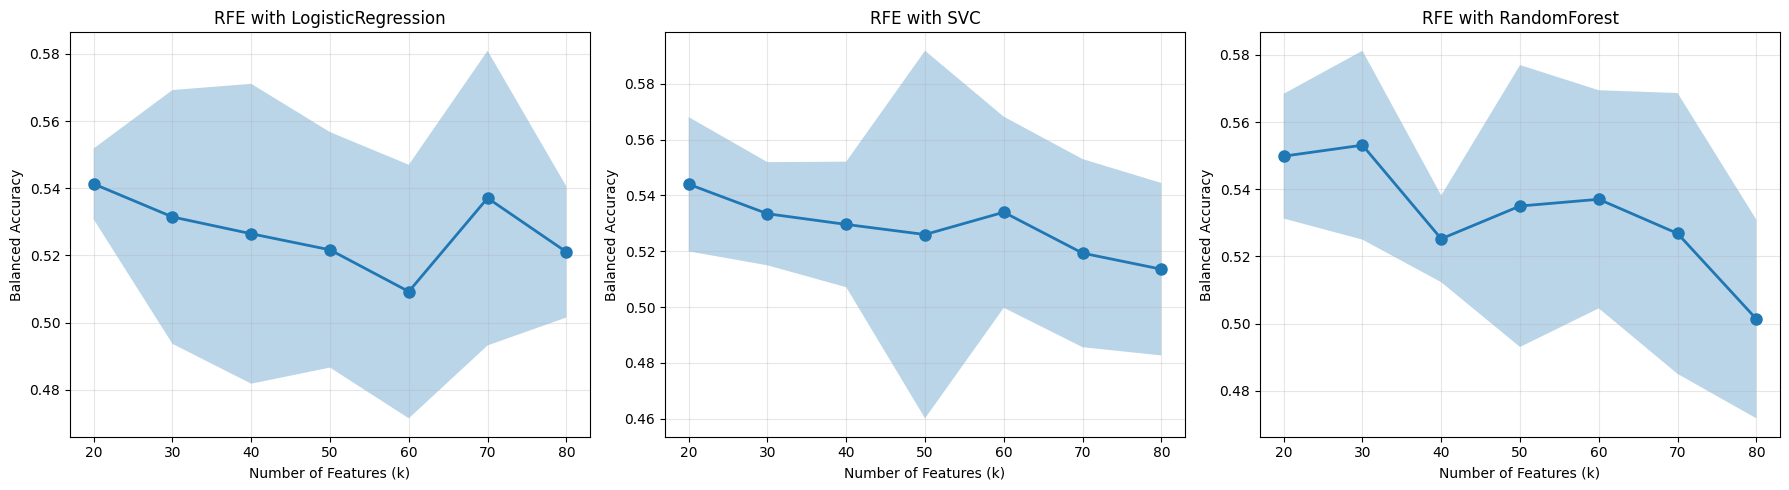


Selected 30 features using RFE (RandomForest_k30)


In [158]:
# Visualize RFE results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, est_name in enumerate(estimators_rfe.keys()):
    est_results = {k: v for k, v in rfe_results.items() if v['estimator'] == est_name}
    k_vals = sorted([v['k'] for v in est_results.values()])
    scores = [est_results[f"{est_name}_k{k}"]['mean_score'] for k in k_vals]
    stds = [est_results[f"{est_name}_k{k}"]['std_score'] for k in k_vals]
    
    axes[idx].plot(k_vals, scores, marker='o', linewidth=2, markersize=8)
    axes[idx].fill_between(k_vals, [s - std for s, std in zip(scores, stds)], 
                          [s + std for s, std in zip(scores, stds)], alpha=0.3)
    axes[idx].set_xlabel('Number of Features (k)')
    axes[idx].set_ylabel('Balanced Accuracy')
    axes[idx].set_title(f'RFE with {est_name}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSelected {len(rfe_selected_features)} features using RFE ({best_rfe})")


## Feature Selection Technique 4: Random Forest Feature Importance


In [159]:
# Random Forest Feature Importance
rf_importance_results = {}

print("Random Forest Feature Importance Selection")
print("=" * 60)

# Train Random Forest to get feature importance
rf_full = RandomForestClassifier(n_estimators=200, random_state=42)
rf_full.fit(X_scaled_df, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_scaled_df.columns,
    'importance': rf_full.feature_importances_
}).sort_values('importance', ascending=False)

# Test different thresholds and top k
thresholds = [0.001, 0.002, 0.003, 0.004, 0.005]
top_k_values = [20, 30, 40, 50, 60, 70, 80, 90, 100]

# Method 1: Top k features
print("\nMethod 1: Top k features")
for k in top_k_values:
    selected_features = feature_importance.head(k)['feature'].tolist()
    
    # Ensure important features are included
    for imp_feat in important_features:
        if imp_feat not in selected_features:
            selected_features.append(imp_feat)
            if len(selected_features) > k:
                selected_features = selected_features[:k]
    
    # Evaluate
    X_final = X_scaled_df[selected_features]
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X_final, y, cv=cv, scoring='balanced_accuracy')
    
    key = f"topk_{k}"
    rf_importance_results[key] = {
        'features': selected_features,
        'mean_score': scores.mean(),
        'std_score': scores.std(),
        'n_features': len(selected_features),
        'method': 'top_k'
    }
    
    print(f"  k={k}: Balanced Accuracy = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Method 2: Threshold-based
print("\nMethod 2: Threshold-based selection")
for threshold in thresholds:
    selected_features = feature_importance[feature_importance['importance'] >= threshold]['feature'].tolist()
    
    # Ensure important features are included
    for imp_feat in important_features:
        if imp_feat not in selected_features:
            selected_features.append(imp_feat)
    
    if len(selected_features) > 0:
        # Evaluate
        X_final = X_scaled_df[selected_features]
        rf = RandomForestClassifier(n_estimators=100, random_state=42)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(rf, X_final, y, cv=cv, scoring='balanced_accuracy')
        
        key = f"threshold_{threshold}"
        rf_importance_results[key] = {
            'features': selected_features,
            'mean_score': scores.mean(),
            'std_score': scores.std(),
            'n_features': len(selected_features),
            'method': 'threshold'
        }
        
        print(f"  threshold={threshold}: {len(selected_features)} features, Balanced Accuracy = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

# Find best configuration
best_rf = max(rf_importance_results.keys(), key=lambda k: rf_importance_results[k]['mean_score'])
print(f"\nBest RF Importance: {best_rf} with Balanced Accuracy = {rf_importance_results[best_rf]['mean_score']:.4f}")
rf_selected_features = rf_importance_results[best_rf]['features']


Random Forest Feature Importance Selection

Method 1: Top k features
  k=20: Balanced Accuracy = 0.5608 (+/- 0.0389)
  k=30: Balanced Accuracy = 0.5546 (+/- 0.0579)
  k=40: Balanced Accuracy = 0.5350 (+/- 0.0684)
  k=50: Balanced Accuracy = 0.5248 (+/- 0.0632)
  k=60: Balanced Accuracy = 0.5476 (+/- 0.0765)
  k=70: Balanced Accuracy = 0.5433 (+/- 0.0650)
  k=80: Balanced Accuracy = 0.5316 (+/- 0.0644)
  k=90: Balanced Accuracy = 0.5253 (+/- 0.0938)
  k=100: Balanced Accuracy = 0.5253 (+/- 0.0977)

Method 2: Threshold-based selection
  threshold=0.001: 118 features, Balanced Accuracy = 0.5152 (+/- 0.0339)
  threshold=0.002: 117 features, Balanced Accuracy = 0.5253 (+/- 0.0977)
  threshold=0.003: 113 features, Balanced Accuracy = 0.5077 (+/- 0.0359)
  threshold=0.004: 110 features, Balanced Accuracy = 0.5214 (+/- 0.0647)
  threshold=0.005: 98 features, Balanced Accuracy = 0.4943 (+/- 0.0510)

Best RF Importance: topk_20 with Balanced Accuracy = 0.5608


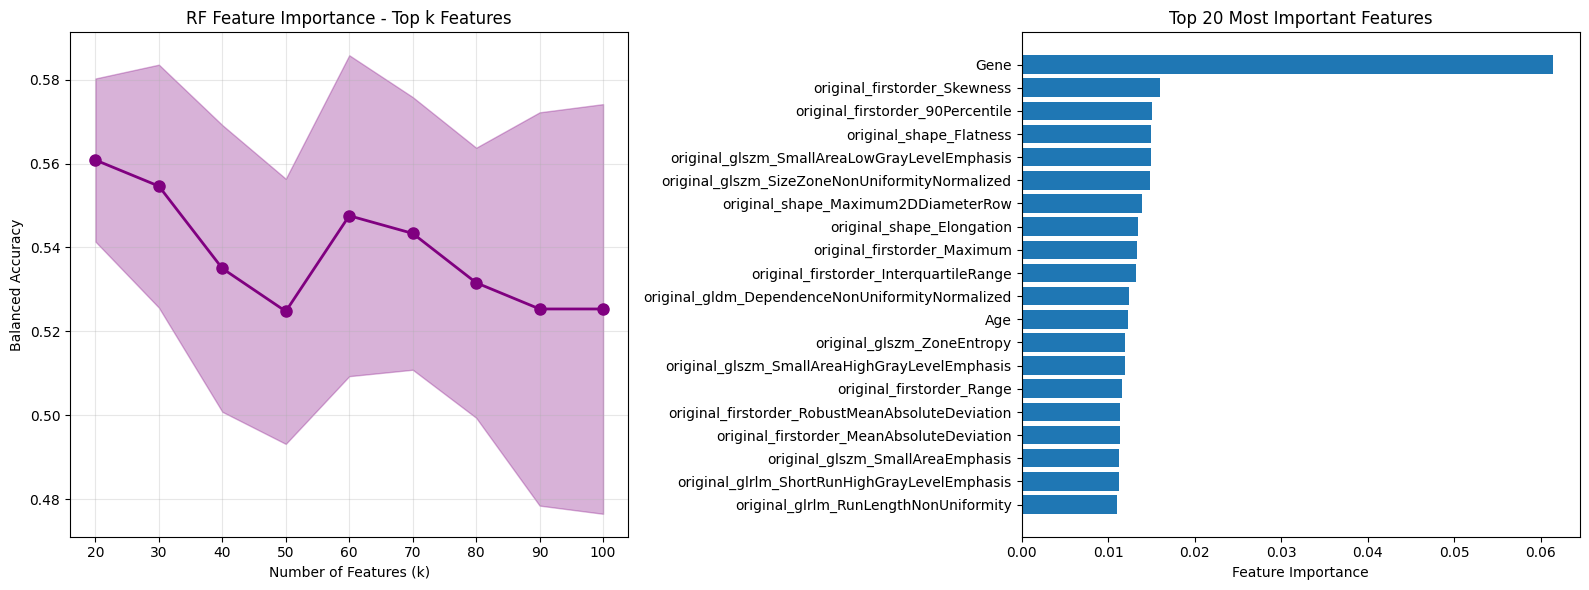


Selected 20 features using RF Importance (topk_20)


In [160]:
# Visualize Random Forest importance results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top k results
topk_results = {k: v for k, v in rf_importance_results.items() if v['method'] == 'top_k'}
k_vals = sorted([int(k.split('_')[1]) for k in topk_results.keys()])
scores = [topk_results[f"topk_{k}"]['mean_score'] for k in k_vals]
stds = [topk_results[f"topk_{k}"]['std_score'] for k in k_vals]

axes[0].plot(k_vals, scores, marker='o', linewidth=2, markersize=8, color='purple')
axes[0].fill_between(k_vals, [s - std for s, std in zip(scores, stds)], 
                     [s + std for s, std in zip(scores, stds)], alpha=0.3, color='purple')
axes[0].set_xlabel('Number of Features (k)')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('RF Feature Importance - Top k Features')
axes[0].grid(True, alpha=0.3)

# Plot 2: Feature importance bar plot (top 20)
top_20_features = feature_importance.head(20)
axes[1].barh(range(len(top_20_features)), top_20_features['importance'].values)
axes[1].set_yticks(range(len(top_20_features)))
axes[1].set_yticklabels(top_20_features['feature'].values)
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Top 20 Most Important Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nSelected {len(rf_selected_features)} features using RF Importance ({best_rf})")


## Summary: Compare All Feature Selection Methods


In [161]:
# Store all selected feature sets
all_feature_selections = {
    'ANOVA': {
        'features': anova_selected_features,
        'score': anova_results[best_k_anova]['mean_score'],
        'std': anova_results[best_k_anova]['std_score'],
        'n_features': len(anova_selected_features),
        'config': f'k={best_k_anova}'
    },
    'Chi-square': {
        'features': chi2_selected_features,
        'score': chi2_results[best_k_chi2]['mean_score'],
        'std': chi2_results[best_k_chi2]['std_score'],
        'n_features': len(chi2_selected_features),
        'config': f'k={best_k_chi2}'
    },
    'RFE': {
        'features': rfe_selected_features,
        'score': rfe_results[best_rfe]['mean_score'],
        'std': rfe_results[best_rfe]['std_score'],
        'n_features': len(rfe_selected_features),
        'config': best_rfe
    },
    'RF_Importance': {
        'features': rf_selected_features,
        'score': rf_importance_results[best_rf]['mean_score'],
        'std': rf_importance_results[best_rf]['std_score'],
        'n_features': len(rf_selected_features),
        'config': best_rf
    }
}

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Method': list(all_feature_selections.keys()),
    'Balanced_Accuracy': [v['score'] for v in all_feature_selections.values()],
    'Std': [v['std'] for v in all_feature_selections.values()],
    'N_Features': [v['n_features'] for v in all_feature_selections.values()],
    'Configuration': [v['config'] for v in all_feature_selections.values()]
}).sort_values('Balanced_Accuracy', ascending=False)



print(comparison_df.to_string(index=False))



       Method  Balanced_Accuracy      Std  N_Features    Configuration
        ANOVA           0.604944 0.064510           5              k=5
   Chi-square           0.570919 0.032119           5              k=5
RF_Importance           0.560841 0.019440          20          topk_20
          RFE           0.553103 0.028119          30 RandomForest_k30


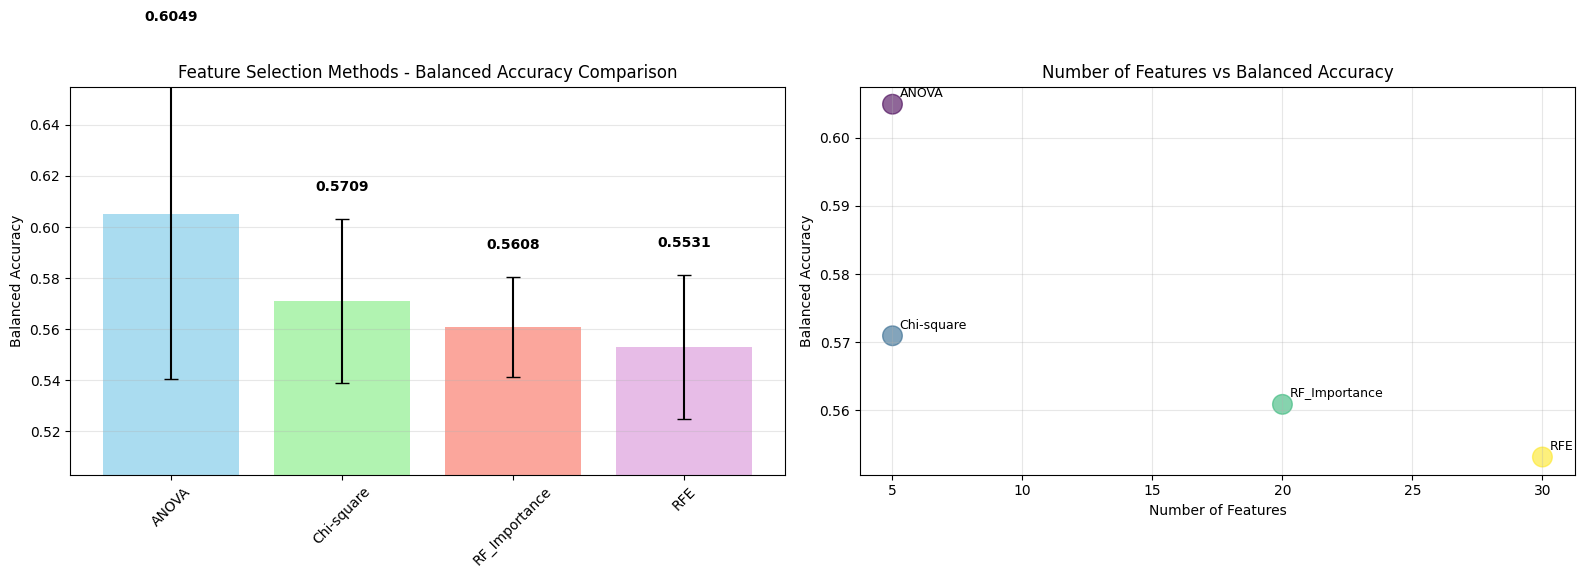

In [162]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Balanced Accuracy comparison
methods = comparison_df['Method'].values
scores = comparison_df['Balanced_Accuracy'].values
stds = comparison_df['Std'].values

bars = axes[0].bar(methods, scores, yerr=stds, capsize=5, alpha=0.7, 
                   color=['skyblue', 'lightgreen', 'salmon', 'plum'])
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Feature Selection Methods - Balanced Accuracy Comparison')
axes[0].set_ylim([min(scores) - 0.05, max(scores) + 0.05])
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, (bar, score) in enumerate(zip(bars, scores)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + stds[i] + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Number of features vs accuracy
axes[1].scatter(comparison_df['N_Features'], comparison_df['Balanced_Accuracy'], 
                s=200, alpha=0.6, c=range(len(comparison_df)), cmap='viridis')
for i, row in comparison_df.iterrows():
    axes[1].annotate(row['Method'], 
                    (row['N_Features'], row['Balanced_Accuracy']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_title('Number of Features vs Balanced Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## Select Best Features and Apply Class Balancing

ANOVA with k=5 works best. Now we'll apply SMOTE Tomek for class balancing.


In [163]:
# Select ANOVA features with k=5
k_selected = 5
selector_anova = SelectKBest(score_func=f_classif, k=k_selected)
X_selected = selector_anova.fit_transform(X_scaled_df, y)
selected_features = X_scaled_df.columns[selector_anova.get_support()].tolist()

# Ensure important features are included
for imp_feat in important_features:
    if imp_feat not in selected_features:
        selected_features.append(imp_feat)

# Get final feature set
X_final = X_scaled_df[selected_features]

print(f"Selected {len(selected_features)} features using ANOVA (k={k_selected})")
print(f"Selected features: {selected_features}")
print(f"\nOriginal class distribution:")
print(y.value_counts())
print(f"\nOriginal class distribution (%):")
print(y.value_counts(normalize=True) * 100)


Selected 5 features using ANOVA (k=5)
Selected features: ['ER', 'PgR', 'HER2', 'Gene', 'missing_Gene']

Original class distribution:
pCR (outcome)
0    316
1     84
Name: count, dtype: int64

Original class distribution (%):
pCR (outcome)
0    79.0
1    21.0
Name: proportion, dtype: float64


## Apply SMOTE Tomek for Class Balancing


In [ ]:
# Apply SMOTE Tomek for class balancing

try:
    from imblearn.combine import SMOTETomek
    smt = SMOTETomek(random_state=42)
    X_balanced, y_balanced = smt.fit_resample(X_final, y)
    method_name = "SMOTETomek"
except (ImportError, AttributeError) as e:
    print(f"SMOTETomek import failed: {e}")
    print("Using SMOTE + TomekLinks separately as fallback...")
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import TomekLinks
    
    # Apply SMOTE first
    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X_final, y)
    
    # Then apply Tomek Links
    tomek = TomekLinks()
    X_balanced, y_balanced = tomek.fit_resample(X_smote, y_smote)
    method_name = "SMOTE + TomekLinks"

print(f"\nBefore balancing:")

print(f"  Class distribution: {y.value_counts().to_dict()}")


print(f"\nAfter balancing:")

print(f"  Class distribution: {pd.Series(y_balanced).value_counts().to_dict()}")




Before balancing:
  Class distribution: {0: 316, 1: 84}

After balancing:
  Class distribution: {1: 312, 0: 312}


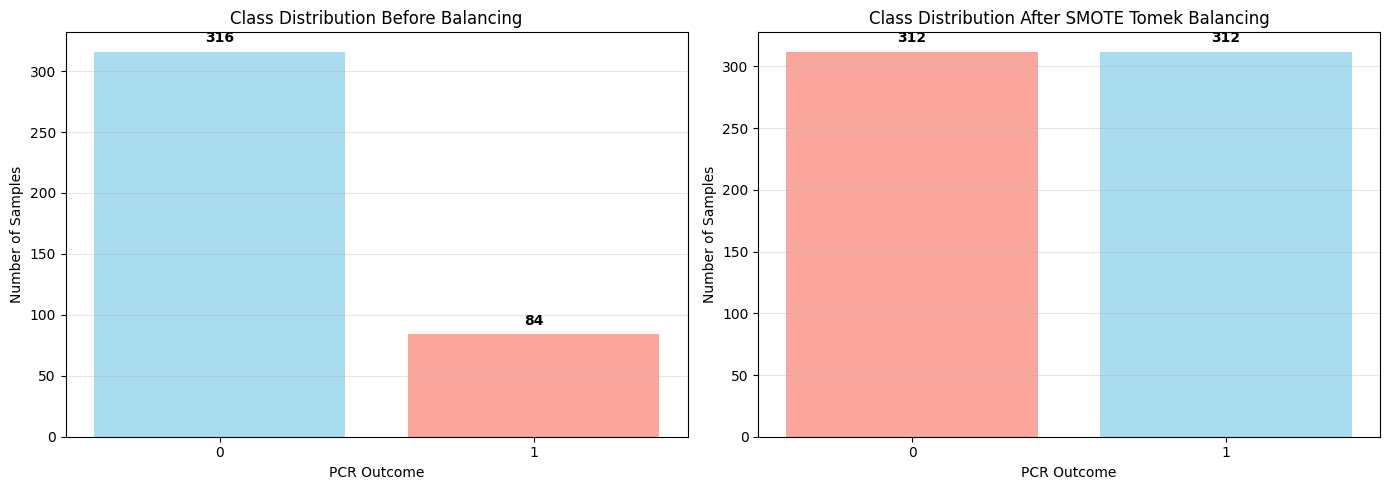

In [165]:
# Class distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before balancing
y_counts_before = y.value_counts()
axes[0].bar(y_counts_before.index, y_counts_before.values, color=['skyblue', 'salmon'], alpha=0.7)
axes[0].set_xlabel('PCR Outcome')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('Class Distribution Before Balancing')
axes[0].set_xticks([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(y_counts_before.values):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

# After balancing
y_counts_after = pd.Series(y_balanced).value_counts()
axes[1].bar(y_counts_after.index, y_counts_after.values, color=['skyblue', 'salmon'], alpha=0.7)
axes[1].set_xlabel('PCR Outcome')
axes[1].set_ylabel('Number of Samples')
axes[1].set_title('Class Distribution After SMOTE Tomek Balancing')
axes[1].set_xticks([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(y_counts_after.values):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



## Model Training and Evaluation



In [ ]:
# Import necessary libraries for model training and evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (balanced_accuracy_score, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, classification_report)
import seaborn as sns

# Prepare train-test split for final evaluation
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, 
                                                    test_size=0.2, random_state=42, 
                                                    stratify=y_balanced)




### Model 1: Logistic Regression


In [167]:
# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Cross-validation evaluation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X_train, y_train, cv=cv, scoring='balanced_accuracy')

# Predictions
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)

# Metrics
train_acc_lr = balanced_accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = balanced_accuracy_score(y_test, y_test_pred_lr)
test_precision_lr = precision_score(y_test, y_test_pred_lr)
test_recall_lr = recall_score(y_test, y_test_pred_lr)
test_f1_lr = f1_score(y_test, y_test_pred_lr)

print("Logistic Regression Results")
print("=" * 60)
print(f"Cross-validation Balanced Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"Training Balanced Accuracy: {train_acc_lr:.4f}")
print(f"Test Balanced Accuracy: {test_acc_lr:.4f}")
print(f"Test Precision: {test_precision_lr:.4f}")
print(f"Test Recall: {test_recall_lr:.4f}")
print(f"Test F1-Score: {test_f1_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

# Store results
lr_results = {
    'model': lr,
    'cv_mean': cv_scores.mean(),
    'cv_std': cv_scores.std(),
    'test_balanced_acc': test_acc_lr,
    'test_precision': test_precision_lr,
    'test_recall': test_recall_lr,
    'test_f1': test_f1_lr,
    'confusion_matrix': cm_lr
}


Logistic Regression Results
Cross-validation Balanced Accuracy: 0.7715 (+/- 0.0903)
Training Balanced Accuracy: 0.7734
Test Balanced Accuracy: 0.7602
Test Precision: 0.7424
Test Recall: 0.7903
Test F1-Score: 0.7656


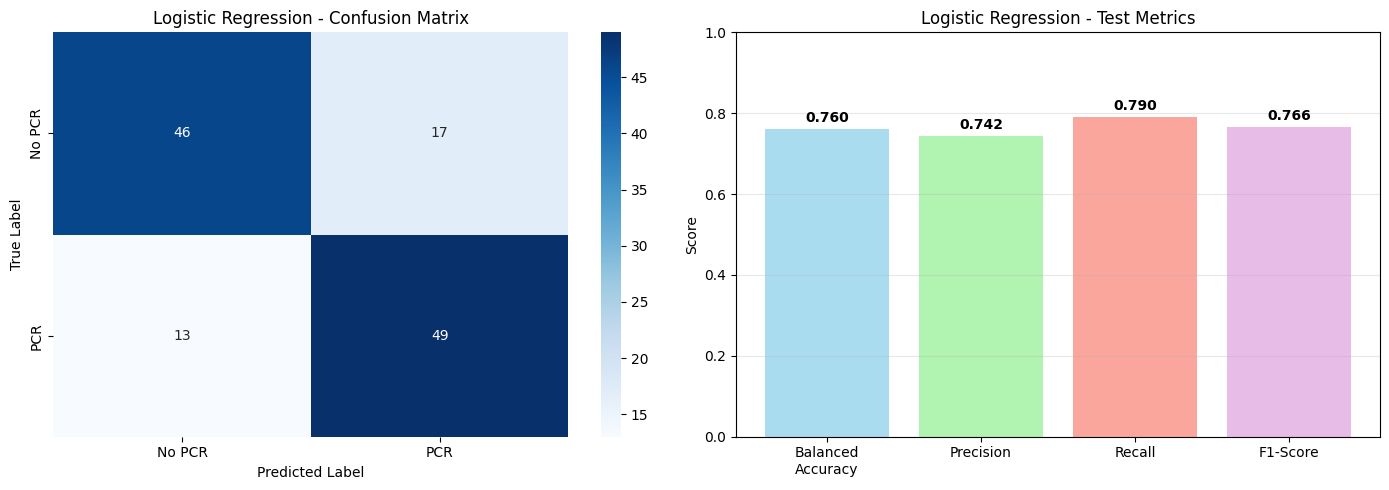

In [168]:
# Visualize Logistic Regression results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No PCR', 'PCR'], yticklabels=['No PCR', 'PCR'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics bar plot
metrics = ['Balanced\nAccuracy', 'Precision', 'Recall', 'F1-Score']
values = [test_acc_lr, test_precision_lr, test_recall_lr, test_f1_lr]
bars = axes[1].bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'plum'], alpha=0.7)
axes[1].set_ylabel('Score')
axes[1].set_title('Logistic Regression - Test Metrics')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Model 2: Support Vector Machine (SVM)


In [ ]:
# Train SVM
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train, y_train)

# Cross-validation evaluation
cv_scores_svm = cross_val_score(svm, X_train, y_train, cv=cv, scoring='balanced_accuracy')

# Predictions
y_train_pred_svm = svm.predict(X_train)
y_test_pred_svm = svm.predict(X_test)

# Metrics
train_acc_svm = balanced_accuracy_score(y_train, y_train_pred_svm)
test_acc_svm = balanced_accuracy_score(y_test, y_test_pred_svm)
test_precision_svm = precision_score(y_test, y_test_pred_svm)
test_recall_svm = recall_score(y_test, y_test_pred_svm)
test_f1_svm = f1_score(y_test, y_test_pred_svm)

print("SVM Results")
print("=" * 60)
print(f"Cross-validation Balanced Accuracy: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std()*2:.4f})")
print(f"Training Balanced Accuracy: {train_acc_svm:.4f}")
print(f"Test Balanced Accuracy: {test_acc_svm:.4f}")
print(f"Test Precision: {test_precision_svm:.4f}")
print(f"Test Recall: {test_recall_svm:.4f}")
print(f"Test F1-Score: {test_f1_svm:.4f}")

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_test_pred_svm)

# Store results
svm_results = {
    'model': svm,
    'cv_mean': cv_scores_svm.mean(),
    'cv_std': cv_scores_svm.std(),
    'test_balanced_acc': test_acc_svm,
    'test_precision': test_precision_svm,
    'test_recall': test_recall_svm,
    'test_f1': test_f1_svm,
    'confusion_matrix': cm_svm
}


SVM Results
Cross-validation Balanced Accuracy: 0.7975 (+/- 0.0847)
Training Balanced Accuracy: 0.8013
Test Balanced Accuracy: 0.7847
Test Precision: 0.7397
Test Recall: 0.8710
Test F1-Score: 0.8000


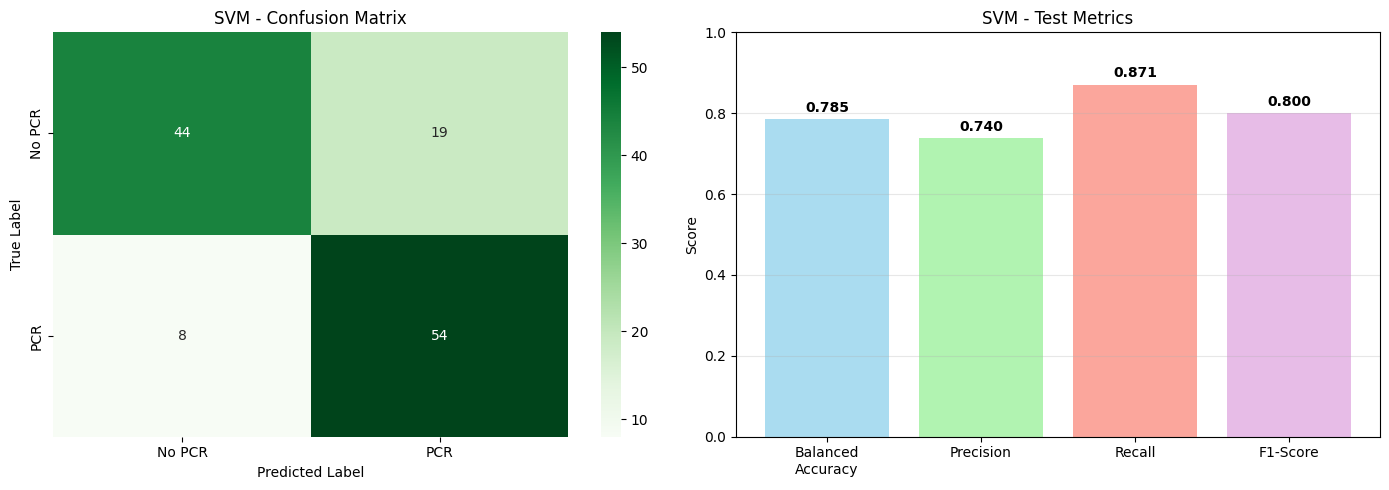

In [ ]:
# Visualize SVM results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['No PCR', 'PCR'], yticklabels=['No PCR', 'PCR'])
axes[0].set_title('SVM - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics bar plot
values = [test_acc_svm, test_precision_svm, test_recall_svm, test_f1_svm]
bars = axes[1].bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'plum'], alpha=0.7)
axes[1].set_ylabel('Score')
axes[1].set_title('SVM - Test Metrics')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Model 3: Random Forest


In [171]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Cross-validation evaluation
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='balanced_accuracy')

# Predictions
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

# Metrics
train_acc_rf = balanced_accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = balanced_accuracy_score(y_test, y_test_pred_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf)
test_recall_rf = recall_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)

print("Random Forest Results")
print("=" * 60)
print(f"Cross-validation Balanced Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std()*2:.4f})")
print(f"Training Balanced Accuracy: {train_acc_rf:.4f}")
print(f"Test Balanced Accuracy: {test_acc_rf:.4f}")
print(f"Test Precision: {test_precision_rf:.4f}")
print(f"Test Recall: {test_recall_rf:.4f}")
print(f"Test F1-Score: {test_f1_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)

# Store results
rf_results = {
    'model': rf,
    'cv_mean': cv_scores_rf.mean(),
    'cv_std': cv_scores_rf.std(),
    'test_balanced_acc': test_acc_rf,
    'test_precision': test_precision_rf,
    'test_recall': test_recall_rf,
    'test_f1': test_f1_rf,
    'confusion_matrix': cm_rf
}


Random Forest Results
Cross-validation Balanced Accuracy: 0.7956 (+/- 0.0777)
Training Balanced Accuracy: 0.8375
Test Balanced Accuracy: 0.8086
Test Precision: 0.7639
Test Recall: 0.8871
Test F1-Score: 0.8209


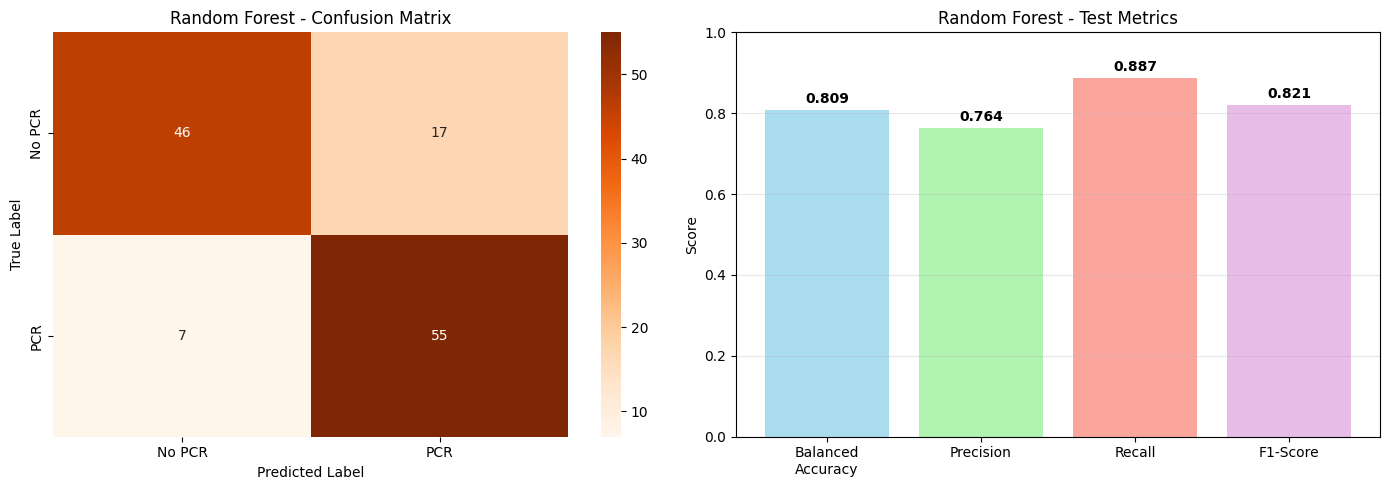

In [ ]:
# Visualize Random Forest results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['No PCR', 'PCR'], yticklabels=['No PCR', 'PCR'])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics bar plot
values = [test_acc_rf, test_precision_rf, test_recall_rf, test_f1_rf]
bars = axes[1].bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'plum'], alpha=0.7)
axes[1].set_ylabel('Score')
axes[1].set_title('Random Forest - Test Metrics')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Model 4: XGBoost


In [173]:
# Train XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Cross-validation evaluation
cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='balanced_accuracy')

# Predictions
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

# Metrics
train_acc_xgb = balanced_accuracy_score(y_train, y_train_pred_xgb)
test_acc_xgb = balanced_accuracy_score(y_test, y_test_pred_xgb)
test_precision_xgb = precision_score(y_test, y_test_pred_xgb)
test_recall_xgb = recall_score(y_test, y_test_pred_xgb)
test_f1_xgb = f1_score(y_test, y_test_pred_xgb)

print("XGBoost Results")
print("=" * 60)
print(f"Cross-validation Balanced Accuracy: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std()*2:.4f})")
print(f"Training Balanced Accuracy: {train_acc_xgb:.4f}")
print(f"Test Balanced Accuracy: {test_acc_xgb:.4f}")
print(f"Test Precision: {test_precision_xgb:.4f}")
print(f"Test Recall: {test_recall_xgb:.4f}")
print(f"Test F1-Score: {test_f1_xgb:.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_test_pred_xgb)

# Store results
xgb_results = {
    'model': xgb,
    'cv_mean': cv_scores_xgb.mean(),
    'cv_std': cv_scores_xgb.std(),
    'test_balanced_acc': test_acc_xgb,
    'test_precision': test_precision_xgb,
    'test_recall': test_recall_xgb,
    'test_f1': test_f1_xgb,
    'confusion_matrix': cm_xgb
}


XGBoost Results
Cross-validation Balanced Accuracy: 0.8016 (+/- 0.0796)
Training Balanced Accuracy: 0.8375
Test Balanced Accuracy: 0.8248
Test Precision: 0.7703
Test Recall: 0.9194
Test F1-Score: 0.8382


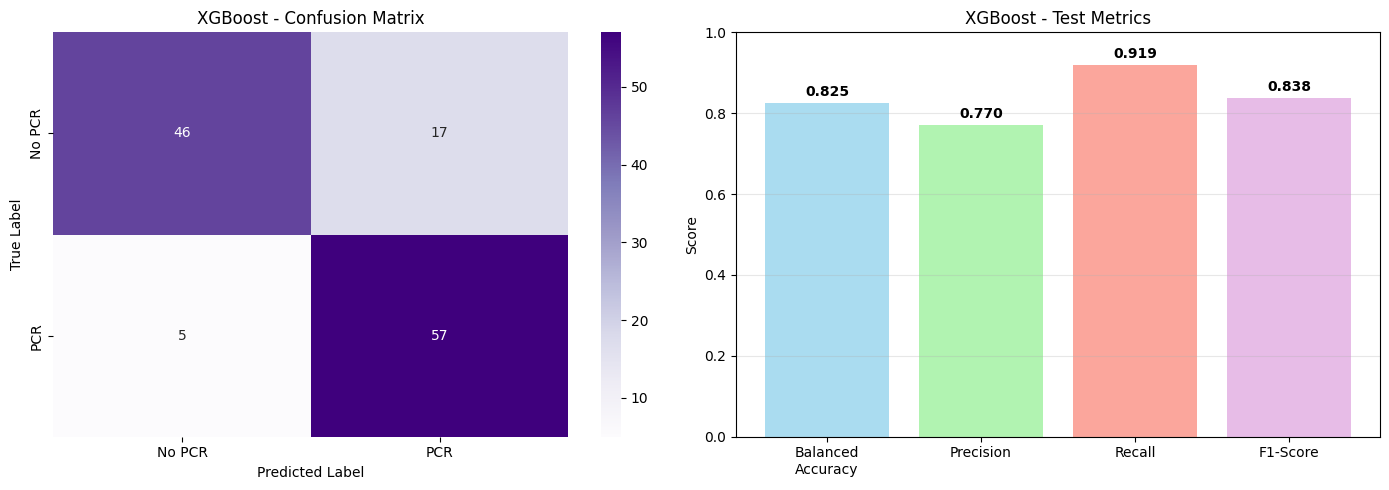

In [174]:
# Visualize XGBoost results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['No PCR', 'PCR'], yticklabels=['No PCR', 'PCR'])
axes[0].set_title('XGBoost - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Metrics bar plot
values = [test_acc_xgb, test_precision_xgb, test_recall_xgb, test_f1_xgb]
bars = axes[1].bar(metrics, values, color=['skyblue', 'lightgreen', 'salmon', 'plum'], alpha=0.7)
axes[1].set_ylabel('Score')
axes[1].set_title('XGBoost - Test Metrics')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## Model Comparison Summary


In [ ]:
# Compare all models
comparison_data = {
    'Model': ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost'],
    'CV Balanced Accuracy': [lr_results['cv_mean'], svm_results['cv_mean'], 
                            rf_results['cv_mean'], xgb_results['cv_mean']],
    'CV Std': [lr_results['cv_std'], svm_results['cv_std'], 
               rf_results['cv_std'], xgb_results['cv_std']],
    'Test Balanced Accuracy': [lr_results['test_balanced_acc'], svm_results['test_balanced_acc'],
                              rf_results['test_balanced_acc'], xgb_results['test_balanced_acc']],
    'Test Precision': [lr_results['test_precision'], svm_results['test_precision'],
                      rf_results['test_precision'], xgb_results['test_precision']],
    'Test Recall': [lr_results['test_recall'], svm_results['test_recall'],
                   rf_results['test_recall'], xgb_results['test_recall']],
    'Test F1-Score': [lr_results['test_f1'], svm_results['test_f1'],
                      rf_results['test_f1'], xgb_results['test_f1']]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Test Balanced Accuracy', ascending=False)

print("Model Comparison Summary")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 80)


Model Comparison Summary
              Model  CV Balanced Accuracy   CV Std  Test Balanced Accuracy  Test Precision  Test Recall  Test F1-Score
            XGBoost              0.801592 0.039820                0.824757        0.770270     0.919355       0.838235
      Random Forest              0.795592 0.038843                0.808628        0.763889     0.887097       0.820896
                SVM              0.797469 0.042353                0.784690        0.739726     0.870968       0.800000
Logistic Regression              0.771469 0.045172                0.760241        0.742424     0.790323       0.765625



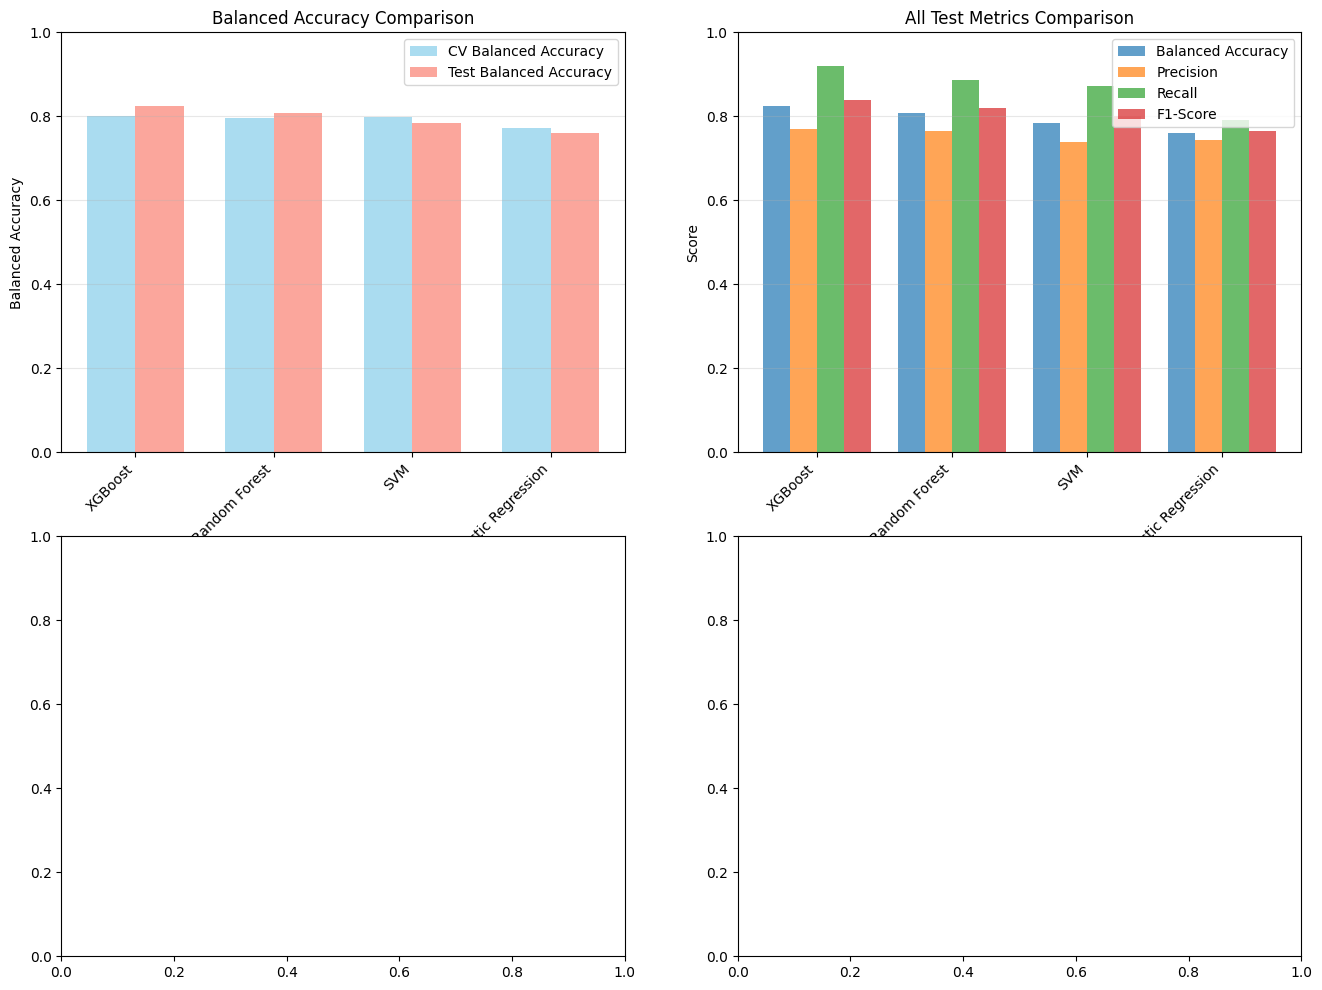

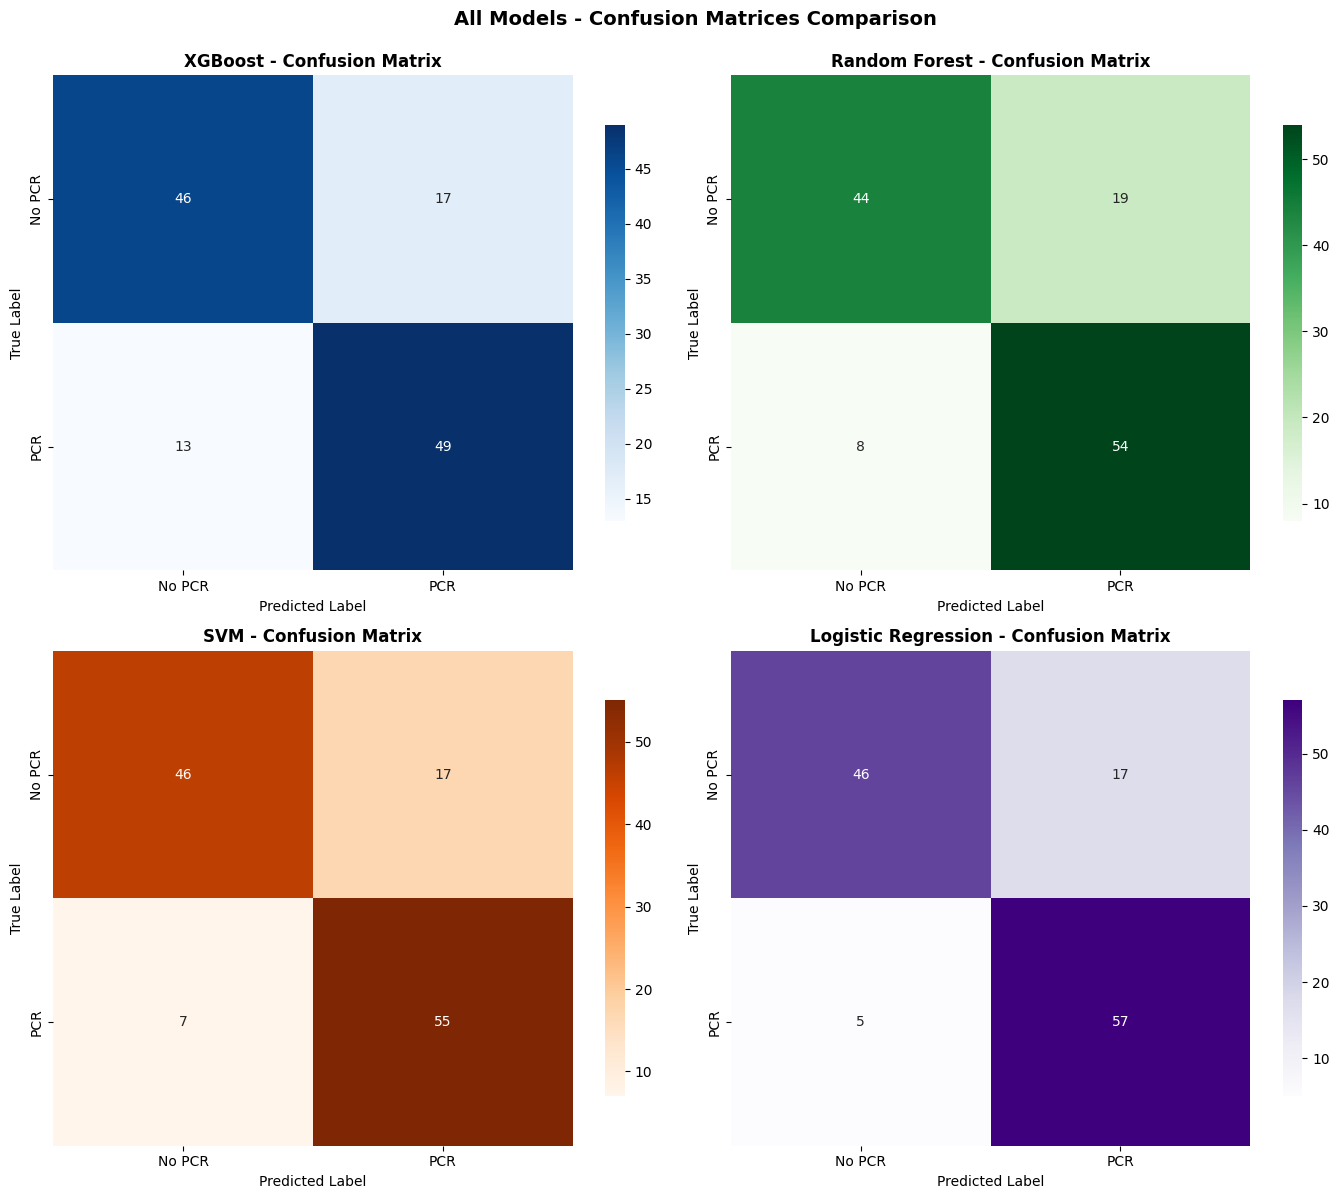


All models trained and evaluated successfully!
Best model based on Test Balanced Accuracy: XGBoost
Best Test Balanced Accuracy: 0.8248


In [ ]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Balanced Accuracy Comparison
models = comparison_df['Model'].values
cv_acc = comparison_df['CV Balanced Accuracy'].values
test_acc = comparison_df['Test Balanced Accuracy'].values
x_pos = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x_pos - width/2, cv_acc, width, label='CV Balanced Accuracy', alpha=0.7, color='skyblue')
axes[0, 0].bar(x_pos + width/2, test_acc, width, label='Test Balanced Accuracy', alpha=0.7, color='salmon')
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('Balanced Accuracy')
axes[0, 0].set_title('Balanced Accuracy Comparison')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylim([0, 1])

# Plot 2: All Test Metrics Comparison
metrics_to_plot = ['Test Balanced Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score']
x = np.arange(len(models))
width = 0.2
for i, metric in enumerate(metrics_to_plot):
    offset = (i - 1.5) * width
    axes[0, 1].bar(x + offset, comparison_df[metric].values, width, label=metric.replace('Test ', ''), alpha=0.7)
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('All Test Metrics Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_ylim([0, 1])

# Plot 3 & 4: Show first 2 confusion matrices
confusion_matrices = [cm_lr, cm_svm, cm_rf, cm_xgb]
cmap_colors = ['Blues', 'Greens', 'Oranges', 'Purples']


# Create separate figure for all 4 confusion matrices
fig, axes_cm = plt.subplots(2, 2, figsize=(14, 12))
for idx, (cm, cmap, model_name) in enumerate(zip(confusion_matrices, cmap_colors, models)):
    row = idx // 2
    col = idx % 2
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes_cm[row, col], 
                xticklabels=['No PCR', 'PCR'], yticklabels=['No PCR', 'PCR'],
                cbar_kws={'shrink': 0.8})
    axes_cm[row, col].set_title(f'{model_name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes_cm[row, col].set_ylabel('True Label', fontsize=10)
    axes_cm[row, col].set_xlabel('Predicted Label', fontsize=10)

plt.suptitle('All Models - Confusion Matrices Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\nAll models trained and evaluated successfully!")
print(f"Best model based on Test Balanced Accuracy: {comparison_df.iloc[0]['Model']}")
print(f"Best Test Balanced Accuracy: {comparison_df.iloc[0]['Test Balanced Accuracy']:.4f}")


## Step 12: XGBoost Hyperparameter Tuning

Since XGBoost performed best, we'll tune its hyperparameters using GridSearchCV to improve performance further.


In [ ]:
# Hyperparameter tuning for XGBoost using GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Create base XGBoost model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# Setup GridSearchCV with balanced accuracy scoring
print("Starting GridSearchCV for XGBoost hyperparameter tuning...")


grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search.fit(X_train, y_train)

print("\nGridSearchCV completed!")
print("=" * 60)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")


Starting GridSearchCV for XGBoost hyperparameter tuning...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearchCV completed!
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation score: 0.8056


### Train and Evaluate Tuned XGBoost Model


In [179]:
# Train the best model from grid search
xgb_tuned = grid_search.best_estimator_

# Make predictions
y_train_pred_tuned = xgb_tuned.predict(X_train)
y_test_pred_tuned = xgb_tuned.predict(X_test)

# Calculate metrics
train_acc_tuned = balanced_accuracy_score(y_train, y_train_pred_tuned)
test_acc_tuned = balanced_accuracy_score(y_test, y_test_pred_tuned)
test_precision_tuned = precision_score(y_test, y_test_pred_tuned)
test_recall_tuned = recall_score(y_test, y_test_pred_tuned)
test_f1_tuned = f1_score(y_test, y_test_pred_tuned)

# Cross-validation on tuned model
cv_scores_tuned = cross_val_score(xgb_tuned, X_train, y_train, cv=cv, scoring='balanced_accuracy')

# Confusion matrix
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)

print("Tuned XGBoost Results")
print("=" * 60)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"\nCross-validation Balanced Accuracy: {cv_scores_tuned.mean():.4f} (+/- {cv_scores_tuned.std()*2:.4f})")
print(f"Training Balanced Accuracy: {train_acc_tuned:.4f}")
print(f"Test Balanced Accuracy: {test_acc_tuned:.4f}")
print(f"Test Precision: {test_precision_tuned:.4f}")
print(f"Test Recall: {test_recall_tuned:.4f}")
print(f"Test F1-Score: {test_f1_tuned:.4f}")


Tuned XGBoost Results
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

Cross-validation Balanced Accuracy: 0.8056 (+/- 0.0909)
Training Balanced Accuracy: 0.8174
Test Balanced Accuracy: 0.7847
Test Precision: 0.7397
Test Recall: 0.8710
Test F1-Score: 0.8000


In [ ]:
# Compare original vs tuned XGBoost
comparison_xgb = pd.DataFrame({
    'Model': ['XGBoost (Original)', 'XGBoost (Tuned)'],
    'CV Balanced Accuracy': [xgb_results['cv_mean'], cv_scores_tuned.mean()],
    'CV Std': [xgb_results['cv_std'], cv_scores_tuned.std()],
    'Test Balanced Accuracy': [xgb_results['test_balanced_acc'], test_acc_tuned],
    'Test Precision': [xgb_results['test_precision'], test_precision_tuned],
    'Test Recall': [xgb_results['test_recall'], test_recall_tuned],
    'Test F1-Score': [xgb_results['test_f1'], test_f1_tuned]
})

print("XGBoost: Original vs Tuned Comparison")
print("=" * 80)
print(comparison_xgb.to_string(index=False))
print("\n" + "=" * 80)

# Calculate improvement
improvement_cv = ((cv_scores_tuned.mean() - xgb_results['cv_mean']) / xgb_results['cv_mean']) * 100
improvement_test = ((test_acc_tuned - xgb_results['test_balanced_acc']) / xgb_results['test_balanced_acc']) * 100

print(f"\nImprovement:")
print(f"  CV Balanced Accuracy: {improvement_cv:+.2f}%")
print(f"  Test Balanced Accuracy: {improvement_test:+.2f}%")


XGBoost: Original vs Tuned Comparison
             Model  CV Balanced Accuracy   CV Std  Test Balanced Accuracy  Test Precision  Test Recall  Test F1-Score
XGBoost (Original)              0.801592 0.039820                0.824757        0.770270     0.919355       0.838235
   XGBoost (Tuned)              0.805551 0.045446                0.784690        0.739726     0.870968       0.800000


Improvement:
  CV Balanced Accuracy: +0.49%
  Test Balanced Accuracy: -4.86%


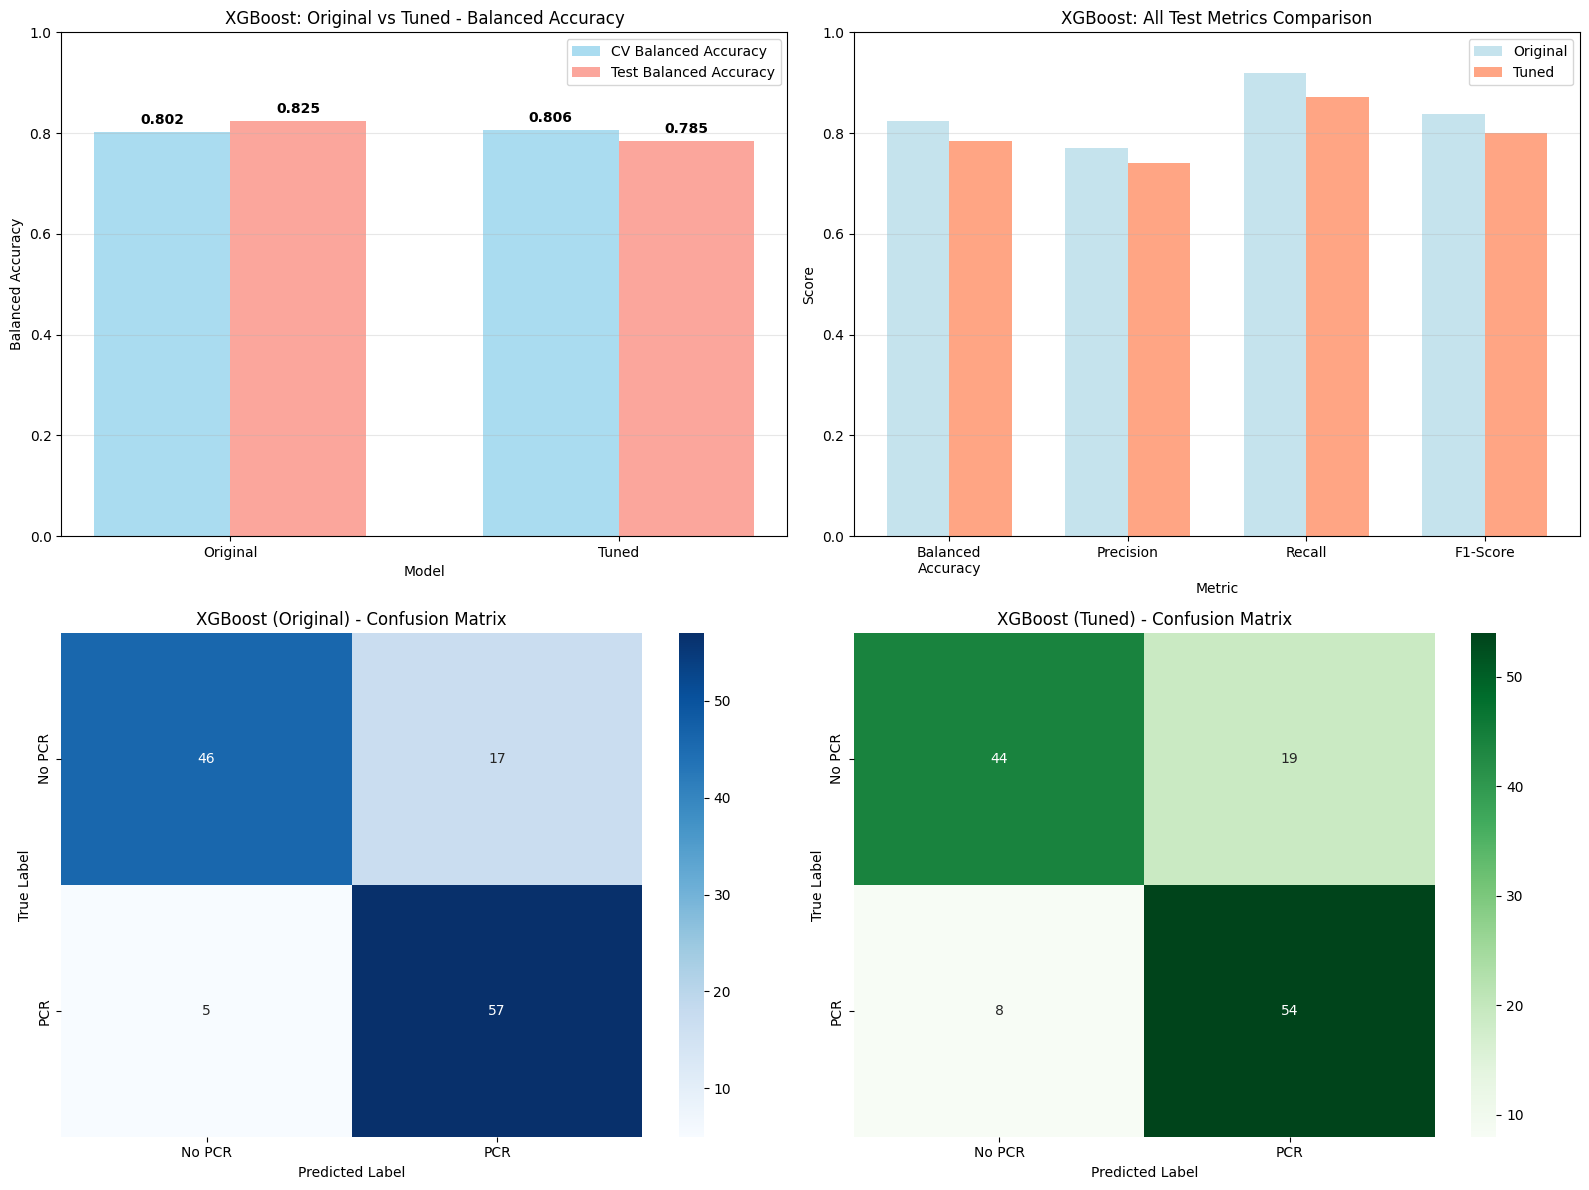

In [181]:
# Visualize Original vs Tuned XGBoost comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Balanced Accuracy Comparison
models_comp = ['Original', 'Tuned']
cv_scores_comp = [xgb_results['cv_mean'], cv_scores_tuned.mean()]
test_scores_comp = [xgb_results['test_balanced_acc'], test_acc_tuned]
x_pos = np.arange(len(models_comp))
width = 0.35

bars1 = axes[0, 0].bar(x_pos - width/2, cv_scores_comp, width, label='CV Balanced Accuracy', 
                       alpha=0.7, color='skyblue')
bars2 = axes[0, 0].bar(x_pos + width/2, test_scores_comp, width, label='Test Balanced Accuracy', 
                       alpha=0.7, color='salmon')
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('Balanced Accuracy')
axes[0, 0].set_title('XGBoost: Original vs Tuned - Balanced Accuracy')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(models_comp)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].set_ylim([0, 1])

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0, 0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: All Metrics Comparison
metrics_names = ['Balanced\nAccuracy', 'Precision', 'Recall', 'F1-Score']
original_metrics = [xgb_results['test_balanced_acc'], xgb_results['test_precision'],
                    xgb_results['test_recall'], xgb_results['test_f1']]
tuned_metrics = [test_acc_tuned, test_precision_tuned, test_recall_tuned, test_f1_tuned]

x = np.arange(len(metrics_names))
width_bar = 0.35
axes[0, 1].bar(x - width_bar/2, original_metrics, width_bar, label='Original', alpha=0.7, color='lightblue')
axes[0, 1].bar(x + width_bar/2, tuned_metrics, width_bar, label='Tuned', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Metric')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('XGBoost: All Test Metrics Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(metrics_names)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_ylim([0, 1])

# Plot 3: Original Confusion Matrix
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['No PCR', 'PCR'], yticklabels=['No PCR', 'PCR'])
axes[1, 0].set_title('XGBoost (Original) - Confusion Matrix')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# Plot 4: Tuned Confusion Matrix
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1, 1],
            xticklabels=['No PCR', 'PCR'], yticklabels=['No PCR', 'PCR'])
axes[1, 1].set_title('XGBoost (Tuned) - Confusion Matrix')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()



## Save Final Model and Preprocessing Objects

The tuned XGBoost was just slightly better in terms of Balanced Classification Accuracy but the original XGBoost performed significantly better in terms of accuracy, precision, recall and f1 score so we'll save the original along with all necessary preprocessing objects for use in the final test script.


In [ ]:
# Save the final model and preprocessing objects
import joblib
import pickle

# Save the original XGBoost model
final_model = xgb 

# Save model
joblib.dump(final_model, 'xgb_pcr_model.pkl')
print("Model saved: xgb_pcr_model.pkl")

# Save scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved: scaler.pkl")

# Save feature selector (ANOVA with k=5)
joblib.dump(selector_anova, 'feature_selector.pkl')
print("Feature selector saved: feature_selector.pkl")

# Save selected features list
with open('selected_features.pkl', 'wb') as f:
    pickle.dump(selected_features, f)
print("Selected features saved: selected_features.pkl")

# Save encoding mappings (for categorical variables)
with open('encoding_mappings.pkl', 'wb') as f:
    pickle.dump(encoding_mappings, f)
print("Encoding mappings saved: encoding_mappings.pkl")

# Save important features list
with open('important_features.pkl', 'wb') as f:
    pickle.dump(important_features, f)
print("Important features saved: important_features.pkl")

# Save the original feature names that the scaler was trained on
training_feature_names = list(X_scaled_df.columns)
with open('training_feature_names.pkl', 'wb') as f:
    pickle.dump(training_feature_names, f)
print("Training feature names saved: training_feature_names.pkl")



Model saved: xgb_pcr_model.pkl
Scaler saved: scaler.pkl
Feature selector saved: feature_selector.pkl
Selected features saved: selected_features.pkl
Encoding mappings saved: encoding_mappings.pkl
Important features saved: important_features.pkl
Training feature names saved: training_feature_names.pkl
